# Module 6

## Pandas

This lecture introduces:

- more advanced Pandas functionality, including `groupby`, categorical datatypes, hierarchical indexing and merging datasets

## Tidy Data

Let's define the following helpful terms:

- variable: a characteristic, number, or quantity that can be measured.
- observation: all of the measurements for a given entity.
- value: a single measurement of a single variable for a given entity.

A **tidy** data frame satisfies the following three criteria (Wickham, 2014):

- each row is a single observation,
- each column is a single variable, and
- each value is a single cell (i.e., its entry in the data frame is not shared with another value).

<img src="https://d33wubrfki0l68.cloudfront.net/6f1ddb544fc5c69a2478e444ab8112fb0eea23f8/91adc/images/tidy-1.png" width="600" />



## Illustration: Diffusion MRI data

Asi in Module 5, we will be working with the [Weston Havens dataset](https://tractometry.org/AFQ-Insight/auto_examples/plot_age_regression.html), preprocessed using pyAFQ. Recall that the preprocessed data consist of following variables:
- subjectID: a unique identifier for each subject
- tractID: a unique identifier for each brain pathway
- nodeID: a unique identifier for each position along the pathway, from 0 to 99
- fa, md, ...: diffusion MRI measurements describing the structural properties of the brain pathway at that specific location

Load the data:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
df = pd.read_csv('https://github.com/tractometry/AFQ-Insight/blob/main/afqinsight/data/classification_data/nodes.csv?raw=true')

In [19]:
df.head()

,subjectID,tractID,nodeID,volume,md,ad,cl,curvature,rd,fa,torsion
0,subject_000,Left Thalamic Radiation,0,88.0,0.964562,1.137844,0.066332,0.052703,0.877920,0.174314,-0.123092
1,subject_000,Left Thalamic Radiation,1,78.0,0.912117,1.139359,0.101223,0.070959,0.798496,0.227283,-0.125926
2,subject_000,Left Thalamic Radiation,2,71.0,0.873796,1.155854,0.139827,0.076268,0.732766,0.281729,-0.350745
3,subject_000,Left Thalamic Radiation,3,78.0,0.851179,1.167977,0.166216,0.065503,0.692781,0.317533,-0.394558
4,subject_000,Left Thalamic Radiation,4,84.0,0.830402,1.164658,0.182578,0.074702,0.663274,0.340960,-0.019610


# Groupby

The `groupby` method:

In [4]:
df.mean(numeric_only=True)

nodeID        49.500000
volume       230.816322
md             0.823420
ad             1.252850
cl             0.224736
curvature      0.069083
rd             0.608705
fa             0.435836
torsion        0.001381
dtype: float64

In [8]:
df.groupby(['subjectID', 'tractID'])['fa'].mean()

#for every subject and every tract, calculate the mean value 
#what variables are you grouping by
#creates a data series 
#has one mean value for every subject and every tract 

subjectID    tractID                  
subject_000  Callosum Forceps Major       0.582243
             Callosum Forceps Minor       0.495415
             Left Arcuate                 0.446109
             Left Cingulum Cingulate      0.438280
             Left Cingulum Hippocampus    0.370431
                                            ...   
subject_047  Right IFOF                   0.455683
             Right ILF                    0.448081
             Right SLF                    0.454822
             Right Thalamic Radiation     0.422307
             Right Uncinate               0.416800
Name: fa, Length: 960, dtype: float64

In [10]:
df_summary = df.groupby(['subjectID', 'tractID'])['fa'].agg(['min', 'mean', 'max'])

#agg does every group by separately 
#agg

Plot the FA along fixed for all subjects:

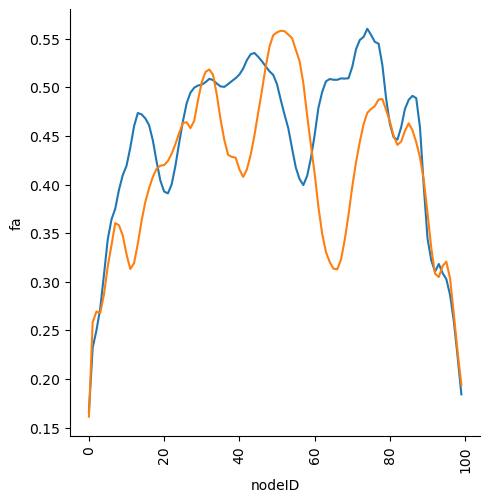

In [11]:
df_tract = df.loc[df['tractID'] == 'Left Arcuate']

sns.relplot(data=df_tract.loc[df_tract['subjectID'].isin(['subject_000', 'subject_001'])],
            x='nodeID',
            y='fa',
            hue='subjectID',
            kind='line',
            legend=False,) # default in relplot is a scatterplot - we want a line plot here
plt.xticks(rotation=90)
plt.show()


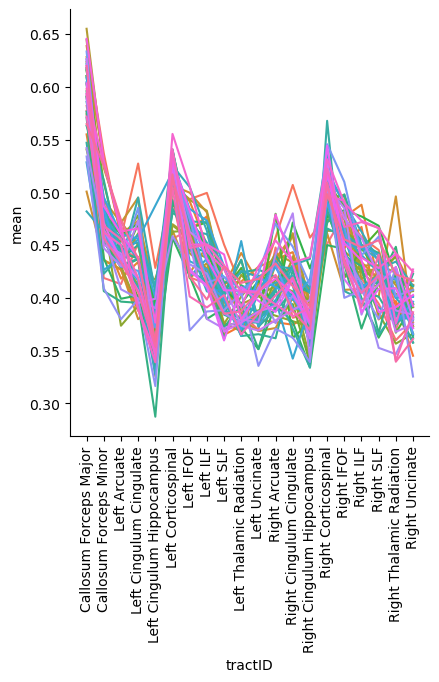

In [ ]:
import matplotlib.pyplot as plt

sns.relplot(data=df_summary,
            x='tractID',
            y='mean',
            hue='subjectID',
            kind='line',
            legend=False,) # default in relplot is a scatterplot - we want a line plot here
plt.xticks(rotation=90)
plt.show()

#uses the df summary data frame 
# x axis is the tract id, y axis is the mean value of fa for each subject and each tract, 
# hue is the subject id, kind is line plot, legend is false because we don't want a legend

In [15]:
sns.relplot(data=df.loc[df_tract['subjectID'].isin(['subject_000', 'subject_001'])],
            x='nodeID',
            y='fa',
            hue='subjectID',
            kind='line',
            col = 'tractID',
            legend=False,) # default in relplot is a scatterplot - we want a line plot here
plt.xticks(rotation=90)
plt.show()

IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

The default behavior in seaborn is to aggregate the multiple measurements at each `x` value by plotting the mean and the 95% confidence interval around the mean, where the confidence interval is calculated using bootstrapping.

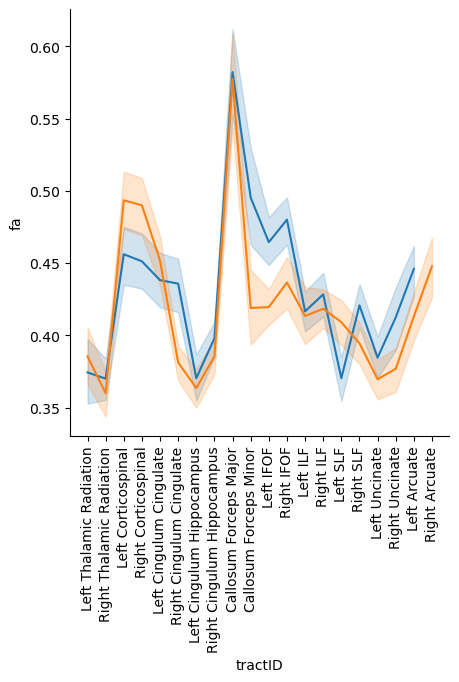

In [16]:
sns.relplot(data=df[df.subjectID.isin(['subject_000', 'subject_001'])],  # filter to two subjects
            x='tractID',
            y='fa',
            hue='subjectID',
            kind='line',
            legend=False)  # default in relplot is a scatterplot - we want a line plot here
plt.xticks(rotation=90)
None

# Categorical Data

Sometimes you see categorical data (e.g. 'Left Thalamic Radiation' etc.) represented as integers, often for ease of data storage. These data will also have a look-up table, so you can tell what integer corresponds to what category.

In [23]:
df.dtypes


df['tractID'].unique()  #number of unique values of tract ID 

<StringArray>
[   'Left Thalamic Radiation',   'Right Thalamic Radiation',
         'Left Corticospinal',        'Right Corticospinal',
    'Left Cingulum Cingulate',   'Right Cingulum Cingulate',
  'Left Cingulum Hippocampus', 'Right Cingulum Hippocampus',
     'Callosum Forceps Major',     'Callosum Forceps Minor',
                  'Left IFOF',                 'Right IFOF',
                   'Left ILF',                  'Right ILF',
                   'Left SLF',                  'Right SLF',
              'Left Uncinate',             'Right Uncinate',
               'Left Arcuate',              'Right Arcuate']
Length: 20, dtype: str

In [ ]:
pd.Categorical(df.tractID) 

#creates categorical variable for tract ID 
#similar to factor variable in R 
#it index the categories with some ID 


['Left Thalamic Radiation', 'Left Thalamic Radiation', 'Left Thalamic Radiation', 'Left Thalamic Radiation', 'Left Thalamic Radiation', ..., 'Right Arcuate', 'Right Arcuate', 'Right Arcuate', 'Right Arcuate', 'Right Arcuate']
Length: 96000
Categories (20, str): ['Callosum Forceps Major', 'Callosum Forceps Minor', 'Left Arcuate', 'Left Cingulum Cingulate', ..., 'Right ILF', 'Right SLF', 'Right Thalamic Radiation', 'Right Uncinate']

In [25]:
list(enumerate(pd.Categorical(df.tractID).categories))

[(0, 'Callosum Forceps Major'),
 (1, 'Callosum Forceps Minor'),
 (2, 'Left Arcuate'),
 (3, 'Left Cingulum Cingulate'),
 (4, 'Left Cingulum Hippocampus'),
 (5, 'Left Corticospinal'),
 (6, 'Left IFOF'),
 (7, 'Left ILF'),
 (8, 'Left SLF'),
 (9, 'Left Thalamic Radiation'),
 (10, 'Left Uncinate'),
 (11, 'Right Arcuate'),
 (12, 'Right Cingulum Cingulate'),
 (13, 'Right Cingulum Hippocampus'),
 (14, 'Right Corticospinal'),
 (15, 'Right IFOF'),
 (16, 'Right ILF'),
 (17, 'Right SLF'),
 (18, 'Right Thalamic Radiation'),
 (19, 'Right Uncinate')]

pandas has a special Categorical extension type for holding data that uses the integer-based categorical representation or encoding. This is a popular data compression technique for data with many occurrences of similar values and can provide significantly faster performance with lower memory use, especially for string data.

In [17]:
tract_ID_string = df['tractID'].copy()

In [26]:
df['tractID'] = df['tractID'].astype('category')

In [27]:
df['tractID']

0        Left Thalamic Radiation
1        Left Thalamic Radiation
2        Left Thalamic Radiation
3        Left Thalamic Radiation
4        Left Thalamic Radiation
                  ...           
95995              Right Arcuate
95996              Right Arcuate
95997              Right Arcuate
95998              Right Arcuate
95999              Right Arcuate
Name: tractID, Length: 96000, dtype: category
Categories (20, str): ['Callosum Forceps Major', 'Callosum Forceps Minor', 'Left Arcuate', 'Left Cingulum Cingulate', ..., 'Right ILF', 'Right SLF', 'Right Thalamic Radiation', 'Right Uncinate']

In [20]:
tract_ID_cat = df['tractID']

In [ ]:
print(tract_ID_cat.memory_usage(deep=True))
print(tract_ID_string.memory_usage(deep=True))

#the categorical variable takes up much less memory than the string variable

97443
6292932


## Binning

Continuous data is often discretized or otherwise separated into “bins” for analysis. 

In [ ]:
df['fa'].describe()



count    93377.000000
mean         0.435836
std          0.113057
min          0.139809
25%          0.359109
50%          0.426970
75%          0.502478
max          0.907006
Name: fa, dtype: float64

In [ ]:
pd.cut(df['fa'], bins=[0.3, 0.45, 0.8], right=False) 
# right=False specifies do not include right value
#define levels of the variable 
#cut into group and create levels for each group 
#modeling continous variable as a binary categorical variable

0                NaN
1                NaN
2                NaN
3        [0.3, 0.45)
4        [0.3, 0.45)
            ...     
95995            NaN
95996            NaN
95997            NaN
95998            NaN
95999            NaN
Name: fa, Length: 96000, dtype: category
Categories (2, interval[float64, left]): [[0.3, 0.45) < [0.45, 0.8)]

## Missing data 

How to get rid of NaNs?

In [ ]:
df.dropna() # drop rows with at least one NaN
#complete case analysis 

,subjectID,tractID,nodeID,volume,md,ad,cl,curvature,rd,fa,torsion
0,subject_000,Left Thalamic Radiation,0,88.0,0.964562,1.137844,0.066332,0.052703,0.877920,0.174314,-0.123092
1,subject_000,Left Thalamic Radiation,1,78.0,0.912117,1.139359,0.101223,0.070959,0.798496,0.227283,-0.125926
2,subject_000,Left Thalamic Radiation,2,71.0,0.873796,1.155854,0.139827,0.076268,0.732766,0.281729,-0.350745
3,subject_000,Left Thalamic Radiation,3,78.0,0.851179,1.167977,0.166216,0.065503,0.692781,0.317533,-0.394558
4,subject_000,Left Thalamic Radiation,4,84.0,0.830402,1.164658,0.182578,0.074702,0.663274,0.340960,-0.019610
...,...,...,...,...,...,...,...,...,...,...,...
95995,subject_047,Right Arcuate,95,107.0,0.774928,1.040073,0.152306,0.061557,0.642356,0.292326,0.000511
95996,subject_047,Right Arcuate,96,107.0,0.758139,1.014998,0.148630,0.065756,0.629709,0.291324,0.432318
95997,subject_047,Right Arcuate,97,127.0,0.743737,0.969239,0.128892,0.086247,0.630986,0.265358,0.243808
95998,subject_047,Right Arcuate,98,118.0,0.748466,0.937630,0.103746,0.073557,0.653884,0.225859,0.191906


We can also fill the NaNs with a particular value if we have some prior knowledge of what the values should be:

In [ ]:
df.fillna(0)

#fill na with pre specified value 

,subjectID,tractID,nodeID,volume,md,ad,cl,curvature,rd,fa,torsion
0,subject_000,Left Thalamic Radiation,0,88.0,0.964562,1.137844,0.066332,0.052703,0.877920,0.174314,-0.123092
1,subject_000,Left Thalamic Radiation,1,78.0,0.912117,1.139359,0.101223,0.070959,0.798496,0.227283,-0.125926
2,subject_000,Left Thalamic Radiation,2,71.0,0.873796,1.155854,0.139827,0.076268,0.732766,0.281729,-0.350745
3,subject_000,Left Thalamic Radiation,3,78.0,0.851179,1.167977,0.166216,0.065503,0.692781,0.317533,-0.394558
4,subject_000,Left Thalamic Radiation,4,84.0,0.830402,1.164658,0.182578,0.074702,0.663274,0.340960,-0.019610
...,...,...,...,...,...,...,...,...,...,...,...
95995,subject_047,Right Arcuate,95,107.0,0.774928,1.040073,0.152306,0.061557,0.642356,0.292326,0.000511
95996,subject_047,Right Arcuate,96,107.0,0.758139,1.014998,0.148630,0.065756,0.629709,0.291324,0.432318
95997,subject_047,Right Arcuate,97,127.0,0.743737,0.969239,0.128892,0.086247,0.630986,0.265358,0.243808
95998,subject_047,Right Arcuate,98,118.0,0.748466,0.937630,0.103746,0.073557,0.653884,0.225859,0.191906


We can fill the values with different values for different columns:

In [26]:
df.fillna({'Left Thalamic Radiation	': 0.5, 'Right Arcuate': 0.6}).fillna(0)

,subjectID,tractID,nodeID,volume,md,ad,cl,curvature,rd,fa,torsion
0,subject_000,Left Thalamic Radiation,0,88.0,0.964562,1.137844,0.066332,0.052703,0.877920,0.174314,-0.123092
1,subject_000,Left Thalamic Radiation,1,78.0,0.912117,1.139359,0.101223,0.070959,0.798496,0.227283,-0.125926
2,subject_000,Left Thalamic Radiation,2,71.0,0.873796,1.155854,0.139827,0.076268,0.732766,0.281729,-0.350745
3,subject_000,Left Thalamic Radiation,3,78.0,0.851179,1.167977,0.166216,0.065503,0.692781,0.317533,-0.394558
4,subject_000,Left Thalamic Radiation,4,84.0,0.830402,1.164658,0.182578,0.074702,0.663274,0.340960,-0.019610
...,...,...,...,...,...,...,...,...,...,...,...
95995,subject_047,Right Arcuate,95,107.0,0.774928,1.040073,0.152306,0.061557,0.642356,0.292326,0.000511
95996,subject_047,Right Arcuate,96,107.0,0.758139,1.014998,0.148630,0.065756,0.629709,0.291324,0.432318
95997,subject_047,Right Arcuate,97,127.0,0.743737,0.969239,0.128892,0.086247,0.630986,0.265358,0.243808
95998,subject_047,Right Arcuate,98,118.0,0.748466,0.937630,0.103746,0.073557,0.653884,0.225859,0.191906


In [27]:
df.mean(numeric_only=True)

nodeID        49.500000
volume       230.816322
md             0.823420
ad             1.252850
cl             0.224736
curvature      0.069083
rd             0.608705
fa             0.435836
torsion        0.001381
dtype: float64

We can fill in with other values, like the mean:

In [28]:
df.fillna(df.mean(numeric_only=True))

,subjectID,tractID,nodeID,volume,md,ad,cl,curvature,rd,fa,torsion
0,subject_000,Left Thalamic Radiation,0,88.0,0.964562,1.137844,0.066332,0.052703,0.877920,0.174314,-0.123092
1,subject_000,Left Thalamic Radiation,1,78.0,0.912117,1.139359,0.101223,0.070959,0.798496,0.227283,-0.125926
2,subject_000,Left Thalamic Radiation,2,71.0,0.873796,1.155854,0.139827,0.076268,0.732766,0.281729,-0.350745
3,subject_000,Left Thalamic Radiation,3,78.0,0.851179,1.167977,0.166216,0.065503,0.692781,0.317533,-0.394558
4,subject_000,Left Thalamic Radiation,4,84.0,0.830402,1.164658,0.182578,0.074702,0.663274,0.340960,-0.019610
...,...,...,...,...,...,...,...,...,...,...,...
95995,subject_047,Right Arcuate,95,107.0,0.774928,1.040073,0.152306,0.061557,0.642356,0.292326,0.000511
95996,subject_047,Right Arcuate,96,107.0,0.758139,1.014998,0.148630,0.065756,0.629709,0.291324,0.432318
95997,subject_047,Right Arcuate,97,127.0,0.743737,0.969239,0.128892,0.086247,0.630986,0.265358,0.243808
95998,subject_047,Right Arcuate,98,118.0,0.748466,0.937630,0.103746,0.073557,0.653884,0.225859,0.191906


For now, let's proceed with dropping the rows which have an NaN value:

## Computing Indicator/Dummy Variables

Another type of transformation for statistical modeling or machine learning applications is converting a categorical variable into a dummy or indicator matrix. If a column in a DataFrame has k distinct values, you would derive a matrix or DataFrame with k columns containing all 1s and 0s. pandas has a pandas.get_dummies function for doing this, though you could also devise one yourself. 

We now introduce a second table from the Weston Havens dataset containing subject-level information.

In [31]:
df_subj = pd.read_csv('https://github.com/tractometry/AFQ-Insight/blob/main/afqinsight/data/classification_data/subjects.csv?raw=true')
df_subj.head()

#every subject has some information 
#can merge the two tables because you have subject ID in both tables 

,Unnamed: 0,subjectID,ALSFRS,ALSFRSbulbar,age,class,diseaseduration,gender
0,0,subject_000,33,12,54,ALS,10,F
1,1,subject_001,18,8,69,ALS,36,M
2,2,subject_002,27,9,55,ALS,23,F
3,3,subject_003,32,12,52,ALS,15,M
4,4,subject_004,19,4,58,ALS,6,F


In [32]:
df_subj.gender
pd.get_dummies(df_subj.gender).head()

# provide variables and panda auto generates data frames with 0 and 1
#binary version of variables 
#gives two columns whether subject is female or male 
#in regression you would only select one column, create a subset 

,F,M
0,True,False
1,False,True
2,True,False
3,False,True
4,True,False


In [33]:
# Some cleaning

df_subj.drop(columns=['Unnamed: 0'], inplace=True)
df_subj["class"] = pd.Categorical(df_subj["class"], categories=['CTRL', 'ALS'])
df_subj["gender"] = pd.Categorical(df_subj["gender"], categories=['M', 'F'])
print(df_subj.dtypes)

subjectID               str
ALSFRS                int64
ALSFRSbulbar          int64
age                   int64
class              category
diseaseduration       int64
gender             category
dtype: object


## Plotting

The default relplot is a scatterplot. We use it here to plot two variants of the ALSFRS (Amyotrophic Lateral Sclerosis Functional Rating Scale score)
- ALSFRS: overall functional status across the full scale.
- ALSFRSbulbar: just the bulbar domain, typically reflecting speech, salivation, and swallowing.

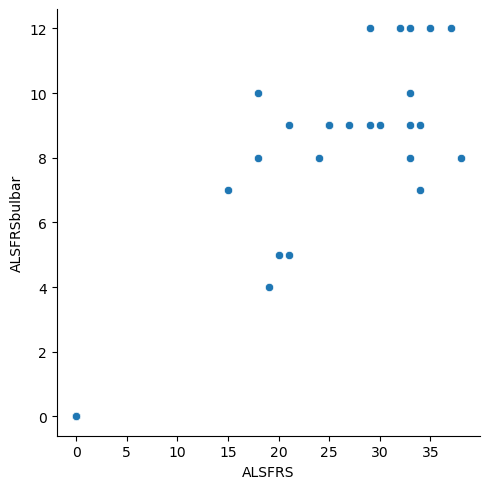

In [ ]:
sns.relplot(data=df_subj,
            x='ALSFRS',
            y='ALSFRSbulbar',
            )

#seaborn is sns 
#sea born is a little more publication ready 

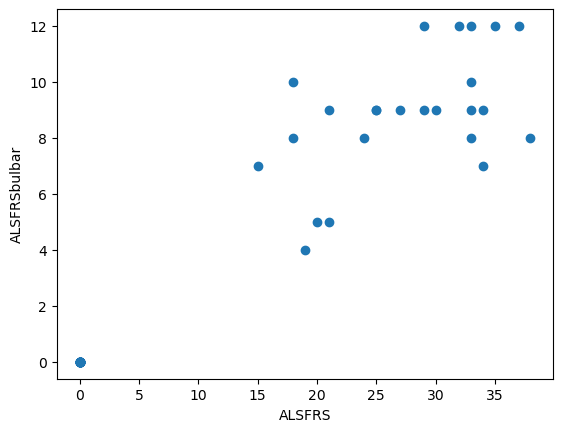

In [33]:
# Similar plot using matplotlib
plt.scatter(
    df_subj["ALSFRS"],
    df_subj["ALSFRSbulbar"],
)

plt.xlabel("ALSFRS")
plt.ylabel("ALSFRSbulbar")
plt.show()

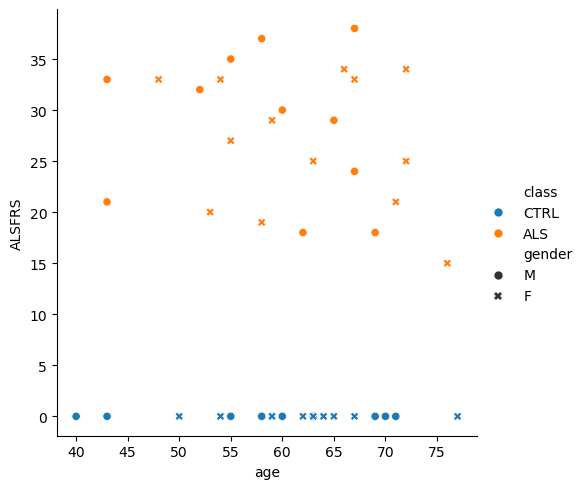

In [ ]:
sns.relplot(data=df_subj,
            x='age',
            y='ALSFRS',
            hue='class',
            style='gender',
            )

#people with score 0 tend to be control subjects 


By default, this function will create a grid of Axes such that each numeric variable in data will by shared across the y-axes across a single row and the x-axes across a single column. 

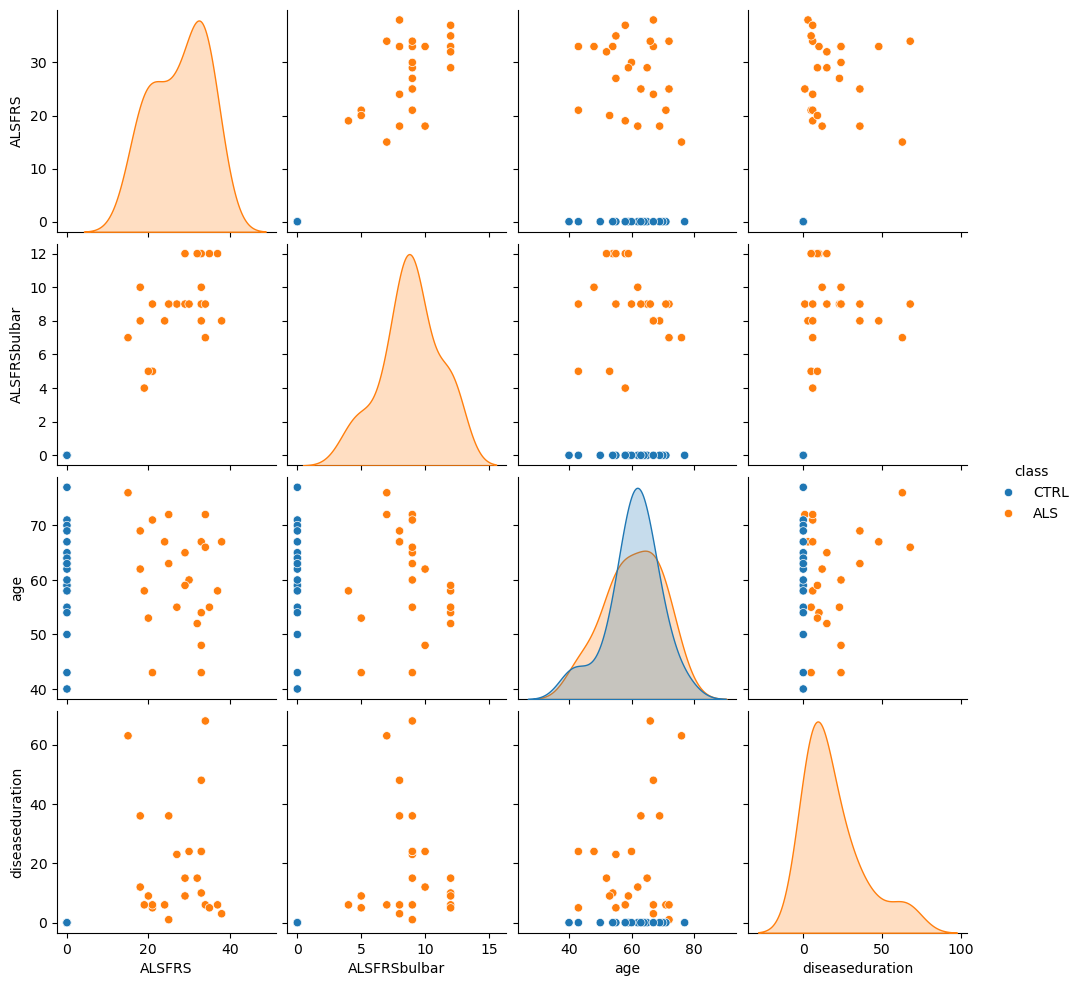

In [ ]:
sns.pairplot(data=df_subj, hue='class')

#all possible pairwise plots in R 
#knows class is a categorical variable so using different colors for different classes

## Hierarchical indexing

Hierarchical indexing is an important feature of pandas that enables you to have multiple (two or more) index levels on an axis.

In [35]:
grouped_df = df.groupby(['subjectID','tractID']).mean(numeric_only=True)

#group by variables you create a multi indedx, every single row is identified by a pair of indexes 


In [ ]:
grouped_df.index
#mean will apply to every single ones of these unique ids 

MultiIndex([('subject_000',     'Callosum Forceps Major'),
            ('subject_000',     'Callosum Forceps Minor'),
            ('subject_000',               'Left Arcuate'),
            ('subject_000',    'Left Cingulum Cingulate'),
            ('subject_000',  'Left Cingulum Hippocampus'),
            ('subject_000',         'Left Corticospinal'),
            ('subject_000',                  'Left IFOF'),
            ('subject_000',                   'Left ILF'),
            ('subject_000',                   'Left SLF'),
            ('subject_000',    'Left Thalamic Radiation'),
            ...
            ('subject_047',              'Left Uncinate'),
            ('subject_047',              'Right Arcuate'),
            ('subject_047',   'Right Cingulum Cingulate'),
            ('subject_047', 'Right Cingulum Hippocampus'),
            ('subject_047',        'Right Corticospinal'),
            ('subject_047',                 'Right IFOF'),
            ('subject_047',             

Here, the columns also have a MultiIndex.

In [38]:
grouped_df.columns

Index(['nodeID', 'volume', 'md', 'ad', 'cl', 'curvature', 'rd', 'fa',
       'torsion'],
      dtype='str')

You can see how many levels an index has by accessing its `nlevels` attribute:

With partial column indexing you can select groups of columns:

In [39]:
grouped_df['fa']

subjectID    tractID                  
subject_000  Callosum Forceps Major       0.582243
             Callosum Forceps Minor       0.495415
             Left Arcuate                 0.446109
             Left Cingulum Cingulate      0.438280
             Left Cingulum Hippocampus    0.370431
                                            ...   
subject_047  Right IFOF                   0.455683
             Right ILF                    0.448081
             Right SLF                    0.454822
             Right Thalamic Radiation     0.422307
             Right Uncinate               0.416800
Name: fa, Length: 960, dtype: float64

In [40]:
grouped_df.loc['subject_022']

,nodeID,volume,md,ad,cl,curvature,rd,fa,torsion
tractID,,,,,,,,,
Callosum Forceps Major,49.5,287.45,0.947766,1.664549,0.364431,0.054378,0.589375,0.563223,0.023290
Callosum Forceps Minor,49.5,265.32,0.931814,1.553458,0.307432,0.068813,0.620992,0.511876,-0.017750
Left Arcuate,49.5,206.87,0.793242,1.198099,0.208343,0.068355,0.590814,0.437051,-0.056420
Left Cingulum Cingulate,49.5,121.23,0.857541,1.325018,0.242464,0.064656,0.623803,0.450356,0.021755
Left Cingulum Hippocampus,49.5,95.18,0.837377,1.223961,0.204126,0.066118,0.644085,0.387248,-0.024692
Left Corticospinal,49.5,377.89,0.760260,1.267083,0.291904,0.044564,0.506848,0.526456,0.023981
Left IFOF,49.5,516.51,0.840250,1.299538,0.237150,0.050224,0.610607,0.452513,-0.053532
Left ILF,49.5,388.14,0.858131,1.279782,0.204575,0.060559,0.647305,0.417233,-0.072527
Left SLF,49.5,218.43,0.776106,1.136743,0.190388,0.079102,0.595788,0.403493,-0.123869


In [41]:
grouped_df.loc['subject_022', "fa"] # works for the level 0 index on the rows or the columns

tractID
Callosum Forceps Major        0.563223
Callosum Forceps Minor        0.511876
Left Arcuate                  0.437051
Left Cingulum Cingulate       0.450356
Left Cingulum Hippocampus     0.387248
Left Corticospinal            0.526456
Left IFOF                     0.452513
Left ILF                      0.417233
Left SLF                      0.403493
Left Thalamic Radiation       0.363968
Left Uncinate                 0.365687
Right Arcuate                 0.361821
Right Cingulum Cingulate      0.426695
Right Cingulum Hippocampus    0.371589
Right Corticospinal           0.484067
Right IFOF                    0.431935
Right ILF                     0.406148
Right SLF                     0.401315
Right Thalamic Radiation      0.374815
Right Uncinate                0.393649
Name: fa, dtype: float64

In [42]:
# we can't do this for "inner level"
# grouped_df.loc['Callosum Forceps Major']

To traverse levels (i.e. get one key from first level and another key from second level), use tuples:

In [43]:
grouped_df.loc[('subject_022', 'Callosum Forceps Major')]

nodeID        49.500000
volume       287.450000
md             0.947766
ad             1.664549
cl             0.364431
curvature      0.054378
rd             0.589375
fa             0.563223
torsion        0.023290
Name: (subject_022, Callosum Forceps Major), dtype: float64

A list is used to specify multiple keys:

In [44]:
grouped_df.loc[['subject_022', 'subject_023'], ["fa", "md"]]

fa        md
subjectID   tractID                                       
subject_022 Callosum Forceps Major      0.563223  0.947766
            Callosum Forceps Minor      0.511876  0.931814
            Left Arcuate                0.437051  0.793242
            Left Cingulum Cingulate     0.450356  0.857541
            Left Cingulum Hippocampus   0.387248  0.837377
            Left Corticospinal          0.526456  0.760260
            Left IFOF                   0.452513  0.840250
            Left ILF                    0.417233  0.858131
            Left SLF                    0.403493  0.776106
            Left Thalamic Radiation     0.363968  0.844810
            Left Uncinate               0.365687  0.857774
            Right Arcuate               0.361821  0.835274
            Right Cingulum Cingulate    0.426695  0.846055
            Right Cingulum Hippocampus  0.371589  0.835182
            Right Corticospinal         0.484067  0.774584
            Right IFOF                  0.431935  0.866862
            Right ILF                   0.406148  0.876073
            Right SLF                   0.401315  0.822903
            Right Thalamic Radiation    0.374815  0.859221
            Right Uncinate              0.393649  0.889669
subject_023 Callosum Forceps Major      0.585982  0.909299
            Callosum Forceps Minor      0.489185  0.867345
            Left Arcuate                0.431430  0.788760
            Left Cingulum Cingulate     0.437143  0.832985
            Left Cingulum Hippocampus   0.353017  0.878556
            Left Corticospinal          0.484897  0.791647
            Left IFOF                   0.451619  0.834128
            Left ILF                    0.418329  0.876734
            Left SLF                    0.405557  0.810765
            Left Thalamic Radiation     0.436249  0.806082
            Left Uncinate               0.372794  0.862790
            Right Arcuate                    NaN       NaN
            Right Cingulum Cingulate    0.405336  0.831398
            Right Cingulum Hippocampus  0.365324  0.849018
            Right Corticospinal         0.465989  0.792493
            Right IFOF                  0.457795  0.800356
            Right ILF                   0.409381  0.851616
            Right SLF                   0.415312  0.791702
            Right Thalamic Radiation    0.418866  0.821738
            Right Uncinate              0.365435  0.879021

It is important to note that tuples and lists are not treated identically in pandas when it comes to indexing. Whereas a tuple is interpreted as one multi-level key, a list is used to specify several keys. Or in other words, tuples go horizontally (traversing levels), lists go vertically (scanning levels).

See more examples here: https://pandas.pydata.org/docs/user_guide/advanced.html#advanced-indexing-with-hierarchical-index

### Summary statistics by level

Many descriptive and summary statistics on DataFrame and Series have a level option in which you can specify the level you want to aggregate by on a particular axis.

In [45]:
grouped_df.groupby(level=0).mean().head()

,nodeID,volume,md,ad,cl,curvature,rd,fa,torsion
subjectID,,,,,,,,,
subject_000,49.5,260.574211,0.800264,1.212192,0.218830,0.067898,0.594300,0.431414,-0.000353
subject_001,49.5,158.447000,0.854473,1.279646,0.214558,0.066664,0.641887,0.420394,-0.005131
subject_002,49.5,296.547895,0.767733,1.216771,0.250601,0.068298,0.543214,0.473211,0.006333
subject_003,49.5,175.886316,0.831785,1.257242,0.220311,0.069844,0.619056,0.427656,0.004131
subject_004,49.5,280.566842,0.850311,1.305666,0.234604,0.064267,0.622633,0.445939,-0.011084


### Cross-sections: Using ``.xs`` to selet subset of rows at a given level

In [46]:
grouped_df.xs('Left Corticospinal', level='tractID').head()

,nodeID,volume,md,ad,cl,curvature,rd,fa,torsion
subjectID,,,,,,,,,
subject_000,49.5,415.99,0.806219,1.255742,0.244583,0.041334,0.581457,0.456214,0.018091
subject_001,49.5,274.16,0.784327,1.265551,0.268786,0.050379,0.543715,0.493581,-0.019966
subject_002,49.5,478.37,0.760493,1.236583,0.261716,0.053118,0.522447,0.507364,0.060575
subject_003,49.5,421.36,0.778931,1.290140,0.292949,0.052967,0.523326,0.523050,0.053845
subject_004,49.5,231.95,0.824971,1.337898,0.279498,0.043039,0.568507,0.507296,-0.005777


# Combining and Merging Datasets

Data contained in pandas objects can be combined in a number of ways:

`pandas.merge`
Connect rows in DataFrames based on one or more keys. This will be familiar to users of SQL or other relational databases, as it implements database join operations.

`pandas.concat`
Concatenate or "stack" objects together along an axis.

## Database-Style DataFrame Joins

Merge or join operations combine datasets by linking rows using one or more keys. These operations are particularly important in relational databases (e.g., SQL-based). The pandas.merge function in pandas is the main entry point for using these algorithms on your data.

In [47]:
df1 = pd.DataFrame({"key": ["b", "b", "a", "c", "a", "a", "b"],
                    "data1": pd.Series(range(7))})

df2 = pd.DataFrame({"key": ["a", "b", "d"],
                    "data2": pd.Series(range(3))})

In [48]:
df1

,key,data1
0,b,0
1,b,1
2,a,2
3,c,3
4,a,4
5,a,5
6,b,6


In [49]:
df2

,key,data2
0,a,0
1,b,1
2,d,2


In [50]:
pd.merge(df1, df2, on='key')

,key,data1,data2
0,b,0,1
1,b,1,1
2,a,2,0
3,a,4,0
4,a,5,0
5,b,6,1


If the column names are different in each object, you can specify them separately:

In [51]:
df3 = pd.DataFrame({"lkey": ["b", "b", "a", "c", "a", "a", "b"],
                    "data1": pd.Series(range(7), dtype="Int64")})

df4 = pd.DataFrame({"rkey": ["a", "b", "d"],
                    "data2": pd.Series(range(3), dtype="Int64")})

pd.merge(df3, df4, left_on="lkey", right_on="rkey")

,lkey,data1,rkey,data2
0,b,0,b,1
1,b,1,b,1
2,a,2,a,0
3,a,4,a,0
4,a,5,a,0
5,b,6,b,1


You may notice that the `"c"` and `"d"` values and associated data are missing from the result. By default, pandas.merge does an `"inner"` join; the keys in the result are the intersection, or the common set found in both tables. Other possible options are `"left"`, `"right"`, and `"outer"`. The outer join takes the union of the keys, combining the effect of applying both left and right joins:

|Option	| Behavior |
|-------|-----------|
|how="inner"	| Use only the key combinations observed in both tables|
|how="left"	| Use all key combinations found in the left table|
|how="right"	| Use all key combinations found in the right table|
|how="outer"	| Use all key combinations observed in both tables together|

In [52]:
pd.merge(df1, df2, how="inner")

,key,data1,data2
0,b,0,1
1,b,1,1
2,a,2,0
3,a,4,0
4,a,5,0
5,b,6,1


In [53]:
pd.merge(df1, df2, how="outer")

,key,data1,data2
0,a,2.0,0.0
1,a,4.0,0.0
2,a,5.0,0.0
3,b,0.0,1.0
4,b,1.0,1.0
5,b,6.0,1.0
6,c,3.0,NaN
7,d,NaN,2.0


In [54]:
pd.merge(df1, df2, how="left")

,key,data1,data2
0,b,0,1.0
1,b,1,1.0
2,a,2,0.0
3,c,3,NaN
4,a,4,0.0
5,a,5,0.0
6,b,6,1.0


In [55]:
pd.merge(df1, df2, how="right")

,key,data1,data2
0,a,2.0,0
1,a,4.0,0
2,a,5.0,0
3,b,0.0,1
4,b,1.0,1
5,b,6.0,1
6,d,NaN,2


### Merging on index

Sometimes, the merge key is in the index (row labels). In this case, use `left_index=True` or `right_index=True` (or both) to indicate the index should be used as merge key.

In [56]:
left1 = pd.DataFrame({"key": ["a", "b", "a", "a", "b", "c"], 
                      "value": pd.Series(range(6), dtype="Int64")})

right1 = pd.DataFrame({"group_val": [3.5, 7]}, index=["a", "b"])

In [57]:
left1

,key,value
0,a,0
1,b,1
2,a,2
3,a,3
4,b,4
5,c,5


In [58]:
right1

,group_val
a,3.5
b,7.0


In [59]:
pd.merge(left1, right1, left_on='key', right_index=True)

,key,value,group_val
0,a,0,3.5
1,b,1,7.0
2,a,2,3.5
3,a,3,3.5
4,b,4,7.0


## Example: MRI dataset

Merge subject level data (`df_subj`) and summary MRI data (`df_summary`)

In [60]:
print(df_subj.head())
print(df_summary.head())

df_summary = df_summary.reset_index()
pd.merge(df_summary, df_subj, on="subjectID")


     subjectID  ALSFRS  ALSFRSbulbar  age class  diseaseduration gender
0  subject_000      33            12   54   ALS               10      F
1  subject_001      18             8   69   ALS               36      M
2  subject_002      27             9   55   ALS               23      F
3  subject_003      32            12   52   ALS               15      M
4  subject_004      19             4   58   ALS                6      F
                                            min      mean       max
subjectID   tractID                                                
subject_000 Callosum Forceps Major     0.256061  0.582243  0.821218
            Callosum Forceps Minor     0.183327  0.495415  0.783863
            Left Arcuate               0.166037  0.446109  0.560233
            Left Cingulum Cingulate    0.183500  0.438280  0.589212
            Left Cingulum Hippocampus  0.171265  0.370431  0.530358


,subjectID,tractID,min,mean,max,ALSFRS,ALSFRSbulbar,age,class,diseaseduration,gender
0,subject_000,Callosum Forceps Major,0.256061,0.582243,0.821218,33,12,54,ALS,10,F
1,subject_000,Callosum Forceps Minor,0.183327,0.495415,0.783863,33,12,54,ALS,10,F
2,subject_000,Left Arcuate,0.166037,0.446109,0.560233,33,12,54,ALS,10,F
3,subject_000,Left Cingulum Cingulate,0.183500,0.438280,0.589212,33,12,54,ALS,10,F
4,subject_000,Left Cingulum Hippocampus,0.171265,0.370431,0.530358,33,12,54,ALS,10,F
...,...,...,...,...,...,...,...,...,...,...,...
955,subject_047,Right IFOF,0.172324,0.455683,0.570975,0,0,58,CTRL,0,M
956,subject_047,Right ILF,0.183597,0.448081,0.653885,0,0,58,CTRL,0,M
957,subject_047,Right SLF,0.175368,0.454822,0.584709,0,0,58,CTRL,0,M
958,subject_047,Right Thalamic Radiation,0.229799,0.422307,0.486961,0,0,58,CTRL,0,M
